# 05 - Inference Pipeline
Full two-stage pipeline: Stage 1 (Mel vs Not Mel) -> Stage 2 (specific disease) with ground-truth comparison, organized outputs, and evaluation statistics.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import yaml
import os
import sys
sys.path.append('..')
import pandas as pd

from torchvision.models import swin_v2_s, Swin_V2_S_Weights
from torch import load,device
from src.classifier.transforms import get_transforms
from src.classifier.model_builder import build_model
from ultralytics import YOLO

from src.inference_utils.inference_pipeline import run_inference_pipeline, compute_pipeline_statistics

with open('../data/processed/Stage-2/model_args.yaml','r') as f:

    s2_model_args = yaml.safe_load(f)


stage1_model = YOLO('../outputs/checkpoints/stage-1/best.pt')

stage2_transform = get_transforms(image_size=256, apply_on_train=False)

stage2_model = swin_v2_s(Swin_V2_S_Weights.DEFAULT)

stage2_model, _, _ = build_model(stage2_model,
                                num_classes=6,
                                lr=s2_model_args['lr'],
                                weight_decay=s2_model_args['weight_decay'],
                                epochs=s2_model_args['epochs'],
                                unfreeze_layers=['features.7', 'norm', 'head'],
                                optimizer_type='sgd',
                                scheduler_type='cosine',
                                dropout=s2_model_args['drop_out'],
                                )

stage2_model.load_state_dict(load('../outputs/checkpoints/stage-2/best.pt', map_location= device(s2_model_args['device_name'])))

TEST_IMAGES_PATH = '../data/processed/Stage-1/test/images'
TEST_LABELS_PATH = '../data/processed/Stage-1/test/labels'

STAGE2_CLASS_NAMES = ['01_AKIEC', '02_BCC', '03_BKL', '04_DF', '05_NV', '06_VASC']

metadata = pd.read_csv('../data/raw/metadata.csv')

Model Loaded: SwinTransformer (num_classes=6)
Head Replaced: 'head' -> Linear(in_features=768, out_features=6)
Backbone Frozen: True | Head Trainable: True
Selective Unfreeze Enabled: ['features.7', 'norm', 'head']
Trainable Parameters: 14,242,230 / 48,973,056 (29.08%)
Optimizer Loaded: SGD (lr=0.0005, momentum=0.9, weight_decay=0.0005)
Scheduler Loaded: CosineAnnealingLR (T_max=50, eta_min=1e-5)
Model Build Complete


## Single image demo (with visualization)

Running inference pipeline:   0%|          | 0/1 [00:00<?, ?it/s]


0: 416x544 12.0ms
Speed: 5.2ms preprocess, 12.0ms inference, 2.6ms postprocess per image at shape (1, 3, 416, 544)


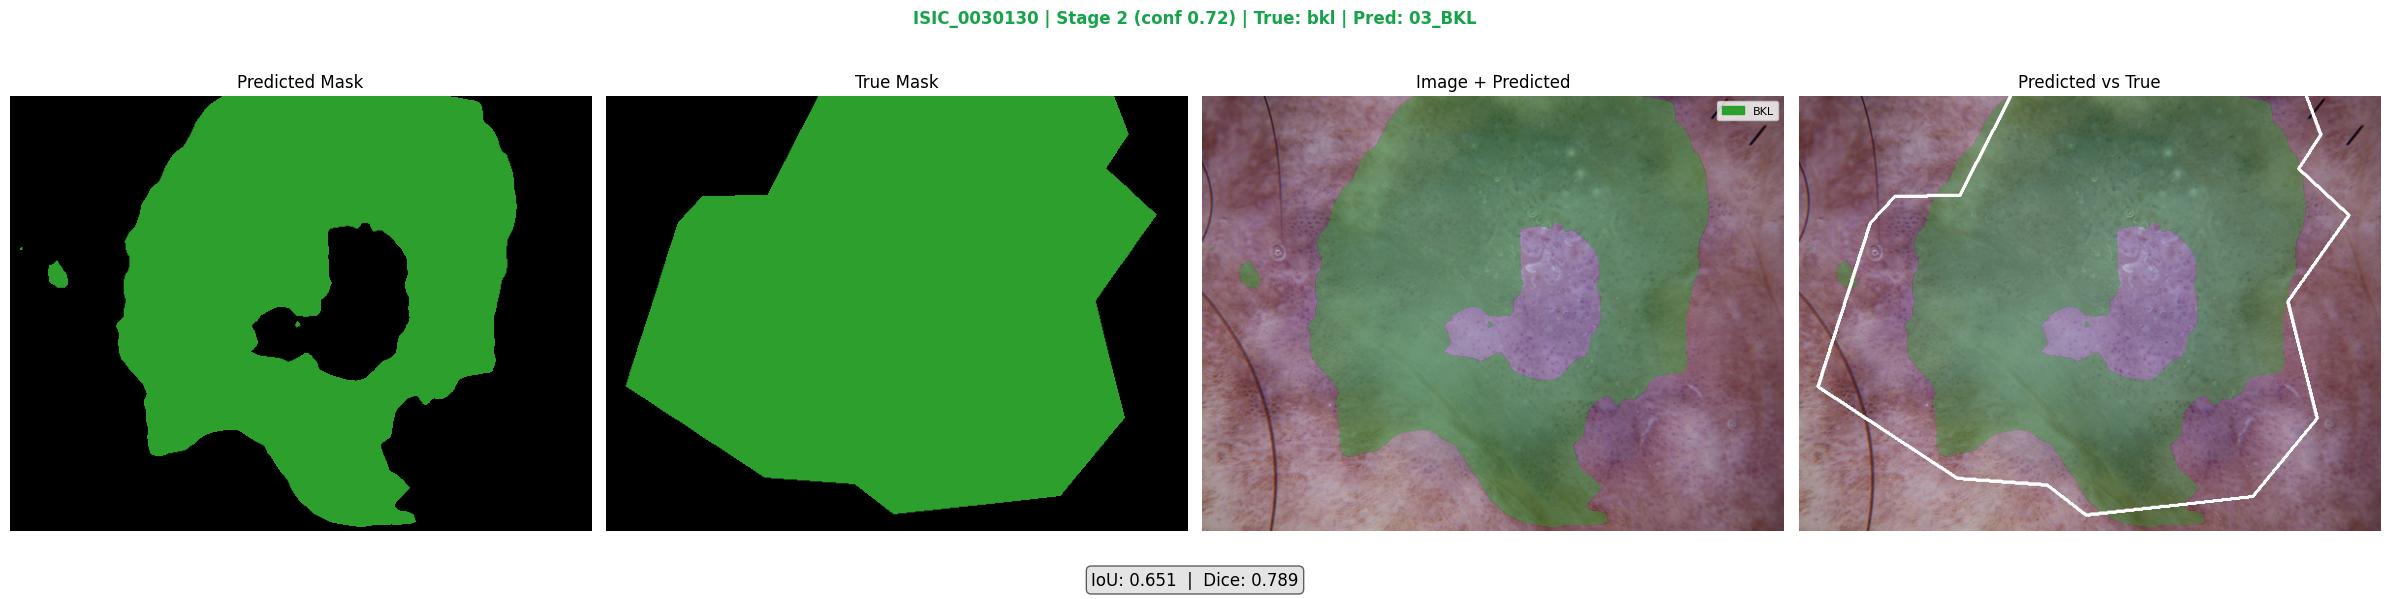

Running inference pipeline: 100%|██████████| 1/1 [00:01<00:00,  1.45s/it]


In [ ]:
image_id = np.random.choice(os.listdir(TEST_IMAGES_PATH)).split('.')[0]

results_df, warnings = run_inference_pipeline(
    stage1_model=stage1_model,
    stage2_model=stage2_model,
    images_path=TEST_IMAGES_PATH,
    ground_truth_path=TEST_LABELS_PATH,
    image_names=image_id,
    stage1_positive_name="Mel",
    stage2_transform=stage2_transform,
    stage2_class_names=STAGE2_CLASS_NAMES, 
    df = metadata,
    save_dir='../outputs/predictions/single_demo'
)

## A specific list of images (with visualization)

Running inference pipeline:   0%|          | 0/3 [00:00<?, ?it/s]


0: 416x544 133.3ms
Speed: 2.6ms preprocess, 133.3ms inference, 5.9ms postprocess per image at shape (1, 3, 416, 544)


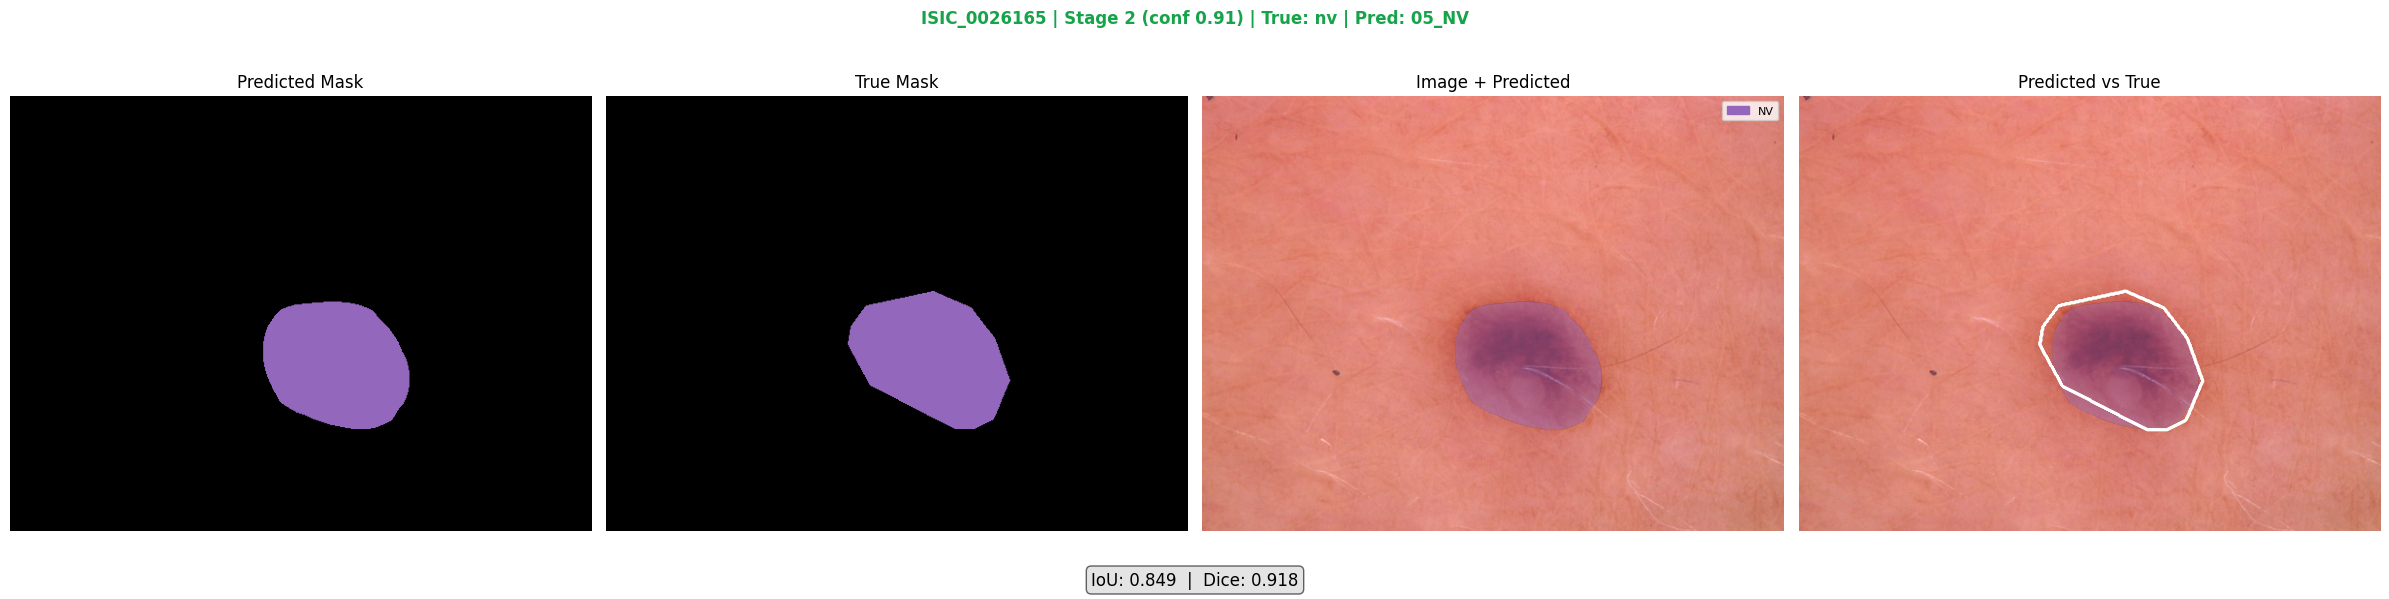

Running inference pipeline:  33%|███▎      | 1/3 [00:01<00:02,  1.41s/it]


0: 416x544 11.8ms
Speed: 1.6ms preprocess, 11.8ms inference, 1.0ms postprocess per image at shape (1, 3, 416, 544)


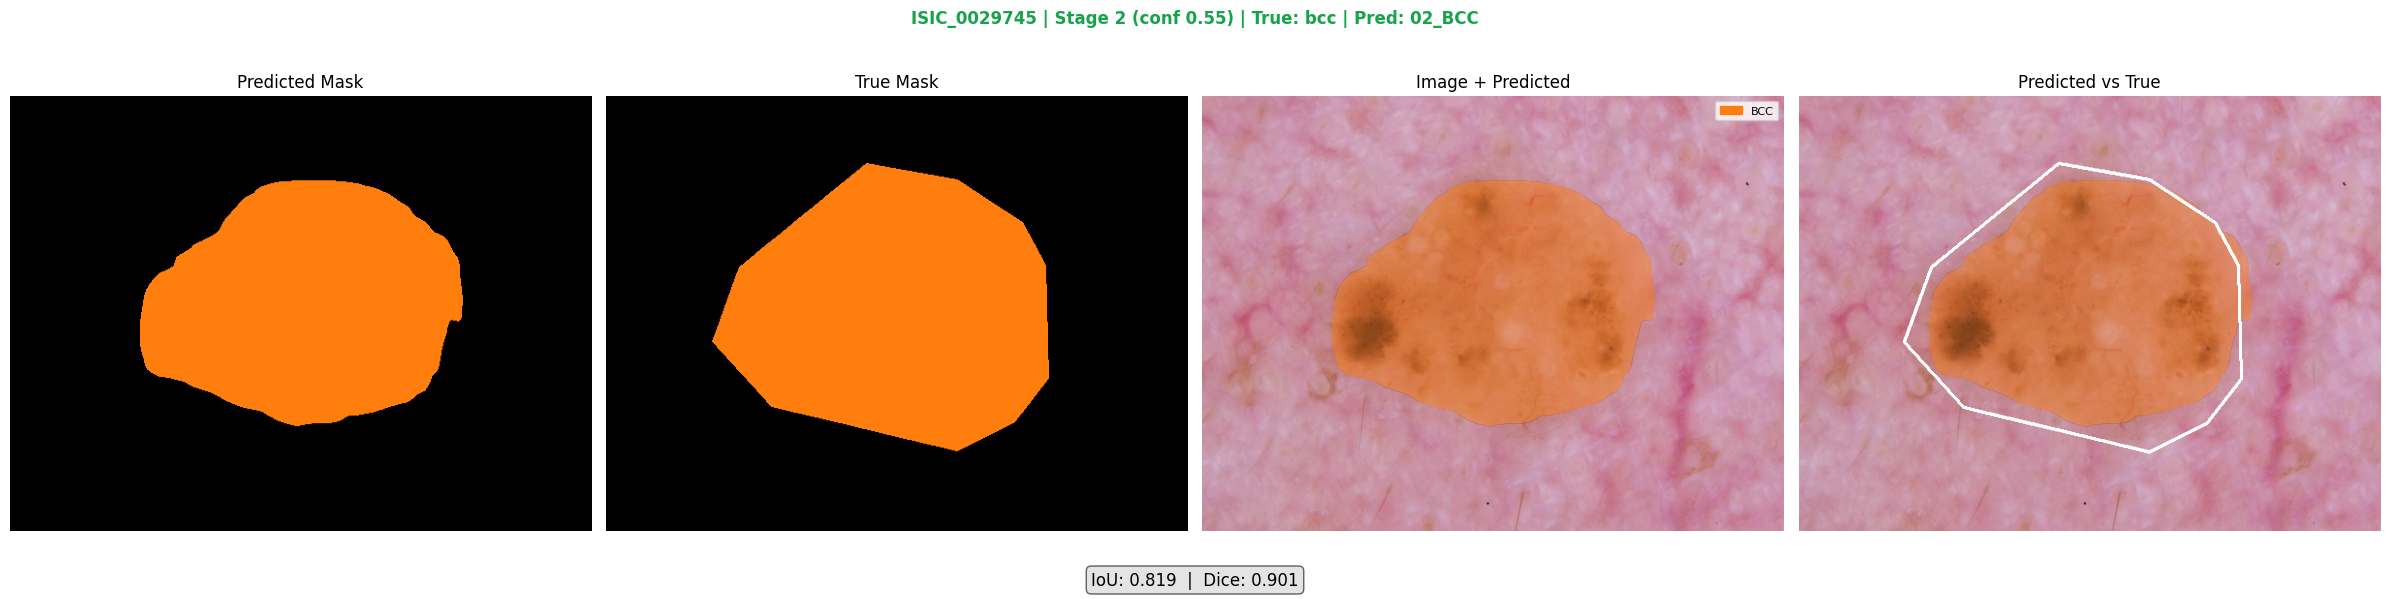

Running inference pipeline:  67%|██████▋   | 2/3 [00:02<00:01,  1.40s/it]


0: 416x544 9.4ms
Speed: 1.9ms preprocess, 9.4ms inference, 0.4ms postprocess per image at shape (1, 3, 416, 544)


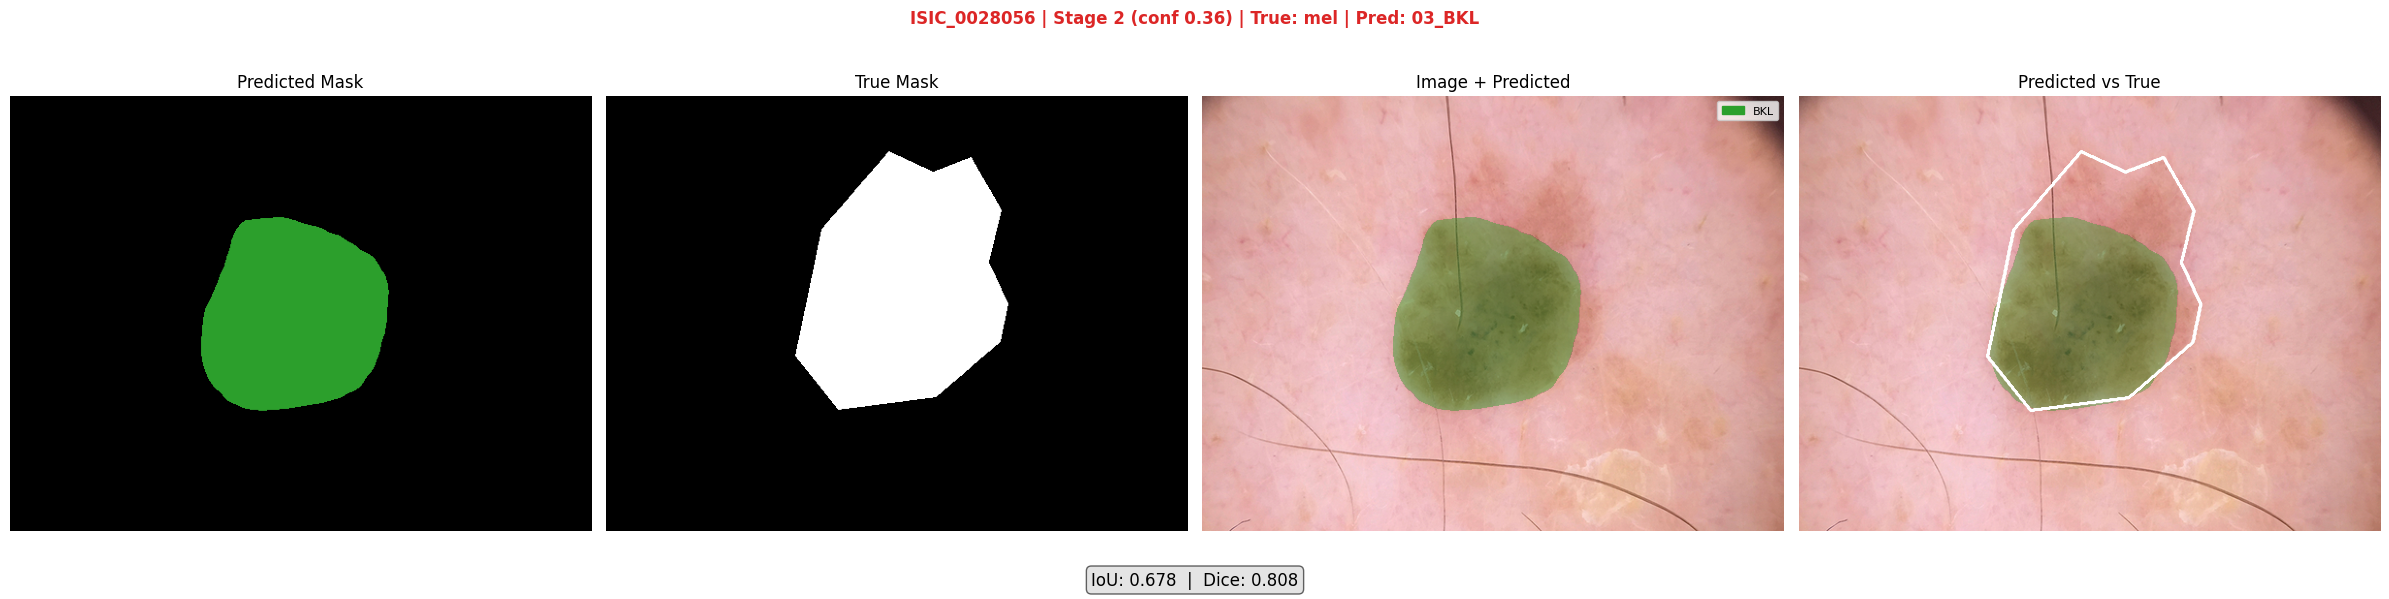

Running inference pipeline: 100%|██████████| 3/3 [00:04<00:00,  1.39s/it]


,image_id,true_dx,stage1_detected,stage1_prediction,true_class_stage1,iou,dice,stage2_prediction,stage2_confidence,final_prediction
0,ISIC_0026165,nv,True,Not Mel,Not Mel,0.848818,0.918228,05_NV,0.906227,05_NV
1,ISIC_0029745,bcc,True,Not Mel,Not Mel,0.819032,0.900514,02_BCC,0.552122,02_BCC
2,ISIC_0028056,mel,True,Not Mel,Mel,0.678213,0.808256,03_BKL,0.359141,03_BKL


In [ ]:
some_images = ['ISIC_0026165.png', 'ISIC_0029745.png', 'ISIC_0028056.png']

results_df, warnings = run_inference_pipeline(
    stage1_model=stage1_model,
    stage2_model=stage2_model,
    images_path=TEST_IMAGES_PATH,
    ground_truth_path=TEST_LABELS_PATH,
    image_names=some_images,
    stage1_positive_name="Mel",
    stage2_transform=stage2_transform,
    stage2_class_names=STAGE2_CLASS_NAMES, 
    df = metadata,
    save_dir='../outputs/predictions/sample_batch'
)

results_df

## Full test set (no visualization, just processing + stats)

In [ ]:
results_df, warnings_list = run_inference_pipeline(
    stage1_model, stage2_model,
    images_path=TEST_IMAGES_PATH,
    ground_truth_path=TEST_LABELS_PATH,
    image_names='all',
    save_dir='../outputs/predictions/full_test_run',
    visualize=False,
    stage2_class_names=STAGE2_CLASS_NAMES,
    stage1_positive_name="Mel",
    stage2_transform=stage2_transform,
    df = metadata,
    
)

print(f"Collected {len(warnings_list)} warnings during this run.")
results_df.head()

Running inference pipeline: 100%|██████████| 618/618 [00:51<00:00, 12.02it/s]

Collected 1 warnings during this run.


,image_id,true_dx,stage1_detected,stage1_prediction,true_class_stage1,iou,dice,stage2_prediction,stage2_confidence,final_prediction
0,ISIC_0024339,nv,True,Not Mel,Not Mel,0.903117,0.949093,05_NV,0.880077,05_NV
1,ISIC_0024345,bcc,True,Not Mel,Not Mel,0.489878,0.657608,02_BCC,0.564027,02_BCC
2,ISIC_0024347,nv,True,Not Mel,Not Mel,0.925877,0.961512,05_NV,0.832696,05_NV
3,ISIC_0024410,mel,True,Not Mel,Mel,0.895390,0.944808,03_BKL,0.617435,03_BKL
4,ISIC_0024431,bcc,True,Not Mel,Not Mel,0.486689,0.654729,02_BCC,0.640902,02_BCC


## Evaluation statistics on the test set

In [19]:
stats = compute_pipeline_statistics(results_df)

for key, value in stats.items():
    if key != 'confusion_counts':
        print(f"{key}: {value}")

total_images: 618
stage1_detection_rate: 0.9919093851132686
stage1_no_detection_rate: 0.008090614886731351
n_images_with_ground_truth_mask: 613
mean_iou: 0.7989774191201158
mean_dice: 0.8760940428157974
stage1_classification_accuracy: 0.799347471451876
stage1_confusion_counts: stage1_prediction  Mel  Not Mel
true_class_stage1              
Mel                 41       79
Not Mel             44      449
stage2_classification_accuracy: 0.7253787878787878
stage2_confusion_counts: stage2_prediction  akiec  bcc  bkl  df   nv  vasc
true_dx                                          
akiec                 19    1    4   1    0     0
bcc                    1   30    3   1    1     0
bkl                    6    2   61   0    7     0
df                     0    1    0   5    2     0
mel                   10    6   29   1   32     1
nv                     1    1   21   2  264     0
vasc                   0    1    1   4    5     4
end_to_end_accuracy: 0.6916802610114192
n_images_scored_end_to_end: 

In [22]:
stats.get('stage1_confusion_counts')

stage1_prediction,Mel,Not Mel
true_class_stage1,,
Mel,41,79
Not Mel,44,449


In [ ]:
stats.get('stage2_confusion_counts')

stage2_prediction,akiec,bcc,bkl,df,nv,vasc
true_dx,,,,,,
akiec,19,1,4,1,0,0
bcc,1,30,3,1,1,0
bkl,6,2,61,0,7,0
df,0,1,0,5,2,0
mel,10,6,29,1,32,1
nv,1,1,21,2,264,0
vasc,0,1,1,4,5,4


## First few collected warnings

In [23]:
for w in warnings_list[:20]:
    print(w)

ISIC_0029926: predicted mask area unusually SMALL (0.05% of image)
